# Per-pixel L2 (L2,1) objective vs current L2 vs L1 — bowtie

The current `dvfopt` L2 objective is `0.5 * Σᵢ Δᵢ²` over all flattened components — a single squared L2 norm across `dx` and `dy` of every pixel. The `Σ` is *inside* the squaring, so a tiny change at one pixel and a tiny change at another contribute additively at the squared level: minimisers naturally **spread** the correction (`T²/k < T²` from the quadratic-sum identity, which is what makes the bowtie's L2 optimum diagonal in `09_horizontal-vs-diagonal-bowtie.ipynb`).

**Proposed alternative** (the user's idea): `Σᵢ √(Δxᵢ² + Δyᵢ²)` — sum the *per-pixel* Euclidean magnitudes. Each pixel's `(Δx, Δy)` is squared and rooted *first*, then magnitudes are summed across pixels. This is the **L2,1 norm** in the standard taxonomy (group-L2 inside, sum-L1 outside).

Properties to expect:

| objective | per-component? | per-pixel? | rewards |
|---|---|---|---|
| **L2 (current)** | quadratic | quadratic | spreading mass over many components, smooth distribution |
| **L1** | absolute value | abs sum | sparse components — favours axis-aligned, single-direction corrections |
| **L2,1 (per-pixel L2)** | quadratic *inside* | absolute value *outside* | sparse *pixels* (like L1) but rotation-invariant within each pixel (unlike L1) |

Concretely, on the bowtie:
- L2 buys the diagonal solution from `09` (final L2 = 0.853, with non-zero `dy` at four pixels).
- L1 buys the horizontal solution (final L1 = 1.420, `dx[3,3] = +0.49`, `dx[3,4] = -0.49`, no `dy`).
- **L2,1 is the interesting one to predict.** It rewards pixel-sparsity (so it should also concentrate the correction on the bowtie pixels rather than spreading) but treats `(Δx, Δy)` per pixel as a single 2-vector (so the dy-tilt that L2 uses isn't free; it's paid for in the same per-pixel magnitude as a dx change).

All three are run on the same 7×7 bowtie with the reactive warm-restart from `11_l1-vs-l2-canonical-cases.ipynb` enabled (so any line-search stall or iter-limit termination is rescued automatically). We report `nit`, `t`, the final value of *all three* metrics for each solution (so a single solution can be cross-scored), and `min_TR` for feasibility.

In [1]:
import os, sys, time, warnings
sys.path.insert(0, os.path.abspath('../..'))
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint

from dvfopt import DEFAULT_PARAMS, jacobian_det2D
from dvfopt.jacobian import triangle_sign_areas2D
from dvfopt.jacobian.triangle_sign import _triangle_areas_2d
from dvfopt.core.objective import objective_euc

THRESHOLD = DEFAULT_PARAMS['threshold']
EPS = 1e-4  # smoothing for L1 and L2,1
print(f'THRESHOLD = {THRESHOLD},  EPS = {EPS}')

THRESHOLD = 0.01,  EPS = 0.0001


In [2]:
def _l2(a, b): return float(np.linalg.norm(a - b))
def _l1(a, b): return float(np.abs(a - b).sum())

def _l21(a, b):
    """Sum of per-pixel Euclidean magnitudes of (a - b).

    Inputs are (2, H, W) phi arrays with channels [dy, dx]. Per pixel (y, x) we
    compute sqrt(diff_dy^2 + diff_dx^2), then sum across pixels. This is the
    unsmoothed L2,1 norm of the displacement difference.
    """
    d = a - b
    return float(np.sqrt((d * d).sum(axis=0)).sum())


def _triangle_flat(dy, dx):
    T1, T2 = _triangle_areas_2d(dy, dx)
    return np.concatenate([T1.flatten(), T2.flatten()])

def _pack(phi):
    # z = [dx_flat | dy_flat]
    return np.concatenate([phi[1].flatten(), phi[0].flatten()])

def _unpack(z, H, W):
    pixels = H * W
    return z[pixels:].reshape(H, W), z[:pixels].reshape(H, W)  # dy, dx


def _make_obj(objective, eps=EPS):
    """Return f(z, z_anchor) -> (value, grad) for the given objective name."""
    if objective == 'l2':
        # 0.5 * ||z - z_anchor||^2 over all flattened components.
        def obj(z, z_anchor):
            return objective_euc(z, z_anchor)
    elif objective == 'l1':
        # Smoothed L1: sum_i sqrt(diff_i^2 + eps^2). Per-component absolute value.
        def obj(z, z_anchor):
            diff = z - z_anchor
            s = np.sqrt(diff * diff + eps * eps)
            return float(s.sum()), diff / s
    elif objective == 'l21':
        # Smoothed L2,1: sum_i sqrt(dx_i^2 + dy_i^2 + eps^2).
        # z is packed as [dx_flat | dy_flat] of length 2 * pixels.
        def obj(z, z_anchor):
            diff = z - z_anchor
            n = diff.size // 2
            ddx = diff[:n]
            ddy = diff[n:]
            mags = np.sqrt(ddx * ddx + ddy * ddy + eps * eps)  # per-pixel, len=n
            val = float(mags.sum())
            grad = np.empty_like(diff)
            grad[:n] = ddx / mags
            grad[n:] = ddy / mags
            return val, grad
    else:
        raise ValueError(objective)
    return obj


def run_slsqp(phi_anchor, objective, max_iter=200, threshold=THRESHOLD,
              warm_start=True, warm_max_iter=1500, warm_ftol=1e-10,
              warm_sigma=0.01, warm_seed=123, eps=EPS):
    """SLSQP with the generalised reactive warm-restart from notebook 11."""
    _, H, W = phi_anchor.shape
    z_anchor = _pack(phi_anchor)
    obj = _make_obj(objective, eps=eps)

    def constr(z):
        dy, dx = _unpack(z, H, W)
        return _triangle_flat(dy, dx)

    nl = NonlinearConstraint(constr, lb=threshold, ub=np.inf)

    t0 = time.time()
    res = minimize(lambda z: obj(z, z_anchor),
                   z_anchor.copy(), jac=True, method='SLSQP',
                   constraints=[nl],
                   options={'maxiter': max_iter, 'ftol': 1e-9, 'disp': False})
    total_nit = res.nit
    warm_fired = False
    warm_reason = ''
    if warm_start and not res.success:
        warm_fired = True
        if res.status == 8:
            rng = np.random.default_rng(warm_seed)
            z_warm = res.x + rng.normal(scale=warm_sigma, size=res.x.shape)
            warm_reason = f'status={res.status} (perturb sigma={warm_sigma})'
        else:
            z_warm = res.x.copy()
            warm_reason = f'status={res.status} (resume with extra budget)'
        res = minimize(lambda z: obj(z, z_anchor),
                       z_warm, jac=True, method='SLSQP',
                       constraints=[nl],
                       options={'maxiter': warm_max_iter, 'ftol': warm_ftol, 'disp': False})
        total_nit += res.nit
    elapsed = time.time() - t0
    dy_out, dx_out = _unpack(res.x, H, W)
    phi_final = np.stack([dy_out, dx_out])
    tri = triangle_sign_areas2D(phi_final)
    return {
        'objective': objective,
        'phi': phi_final,
        'tri': tri,
        'min_tr': float(tri.min()),
        'final_l2': _l2(phi_final, phi_anchor),
        'final_l1': _l1(phi_final, phi_anchor),
        'final_l21': _l21(phi_final, phi_anchor),
        'nit': total_nit,
        't': elapsed,
        'success': bool(res.success),
        'status': int(res.status),
        'warm_fired': warm_fired,
        'warm_reason': warm_reason,
    }


def plot_warped_grid(ax, phi, title, highlight_folds=True, fontsize=8):
    dy, dx = phi[0], phi[1]
    H, W = dy.shape
    yy, xx = np.mgrid[:H, :W]
    gx, gy = xx + dx, yy + dy
    for i in range(H):
        ax.plot(xx[i], yy[i], color='#f0f0f0', lw=0.4)
    for j in range(W):
        ax.plot(xx[:, j], yy[:, j], color='#f0f0f0', lw=0.4)
    for i in range(H):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.8)
    for j in range(W):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.8)
    if highlight_folds:
        tri = triangle_sign_areas2D(phi)
        for (cy, cx) in np.argwhere(tri.min(axis=0) <= 0):
            px = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
            py = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
            ax.plot(px, py, color='#1565c0', lw=1.4)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(title, fontsize=fontsize)
    ax.set_xticks([]); ax.set_yticks([])


def per_pixel_residual_l2(phi_final, phi_anchor):
    """Per-pixel Euclidean magnitude of the displacement difference: shape (H, W)."""
    return np.linalg.norm(phi_final - phi_anchor, axis=0)

In [3]:
H = W = 7
phi_bowtie = np.zeros((2, H, W))
phi_bowtie[1, 3, 3] = +1.2  # phi[1] = dx
phi_bowtie[1, 3, 4] = -1.2

tri = triangle_sign_areas2D(phi_bowtie)
print(f'bowtie shape={phi_bowtie.shape}  n_neg_tri={int((tri<=0).sum())}  '
      f'min_tr={float(tri.min()):+.3f}')

bowtie shape=(2, 7, 7)  n_neg_tri=2  min_tr=-0.700


In [4]:
OBJECTIVES = ['l2', 'l1', 'l21']

results = {}
for objective in OBJECTIVES:
    print(f'>>> {objective.upper():<3s} ...', flush=True)
    r = run_slsqp(phi_bowtie, objective, max_iter=200, warm_start=True,
                  warm_max_iter=1500)
    results[objective] = r
    warm_str = f'(warm fired: {r["warm_reason"]})' if r['warm_fired'] else '(no warm)'
    print(f'    ok={r["success"]!s:<5s} nit={r["nit"]:4d}  t={1000*r["t"]:7.0f}ms  '
          f'L2={r["final_l2"]:.3f}  L1={r["final_l1"]:.3f}  L21={r["final_l21"]:.3f}  '
          f'min_TR={r["min_tr"]:+.3f}  {warm_str}', flush=True)

>>> L2  ...
    ok=True  nit=   6  t=     21ms  L2=0.853  L1=2.190  L21=1.562  min_TR=+0.010  (no warm)
>>> L1  ...
    ok=True  nit= 366  t=   1239ms  L2=1.004  L1=1.420  L21=1.420  min_TR=+0.010  (warm fired: status=9 (resume with extra budget))
>>> L21 ...
    ok=True  nit= 396  t=   1338ms  L2=0.898  L1=1.704  L21=1.270  min_TR=+0.010  (warm fired: status=9 (resume with extra budget))


In [5]:
print(f"{'objective':<10s}  {'ok':>5s}  {'nit':>4s}  {'t(ms)':>7s}  "
      f"{'final L2':>9s}  {'final L1':>9s}  {'final L2,1':>11s}  {'min_TR':>8s}")
print('-' * 80)
for objective in OBJECTIVES:
    r = results[objective]
    print(f'{objective.upper():<10s}  {str(r["success"]):>5s}  {r["nit"]:>4d}  '
          f'{1000*r["t"]:>7.0f}  '
          f'{r["final_l2"]:>9.3f}  {r["final_l1"]:>9.3f}  {r["final_l21"]:>11.3f}  '
          f'{r["min_tr"]:>+8.3f}')

# Cross-score: which objective produces the lowest value of EACH metric?
print()
print('Best objective per metric (lower is better):')
for metric in ('final_l2', 'final_l1', 'final_l21'):
    feasible = {k: v for k, v in results.items() if v['min_tr'] >= THRESHOLD - 1e-9}
    if not feasible:
        feasible = results
    best_obj = min(feasible, key=lambda k: feasible[k][metric])
    print(f'  {metric:<11s}  -> {best_obj.upper():<5s}  (value = {feasible[best_obj][metric]:.3f})')

objective      ok   nit    t(ms)   final L2   final L1   final L2,1    min_TR
--------------------------------------------------------------------------------
L2           True     6       21      0.853      2.190        1.562    +0.010
L1           True   366     1239      1.004      1.420        1.420    +0.010
L21          True   396     1338      0.898      1.704        1.270    +0.010

Best objective per metric (lower is better):
  final_l2     -> L2     (value = 0.853)
  final_l1     -> L1     (value = 1.420)
  final_l21    -> L21    (value = 1.270)


In [6]:
# Verify the L2,1 computation by printing the formula and a per-pixel breakdown
# for each objective's converged solution, then comparing to the stored final_l21.

print('L2,1 norm definition:')
print('  L2,1(phi_final, phi_anchor)  =  sum over pixels p of  sqrt( dy_diff[p]^2 + dx_diff[p]^2 )')
print('  where  dy_diff = (phi_final - phi_anchor)[0],  dx_diff = (phi_final - phi_anchor)[1].')
print('Numpy form (matches the _l21 helper in the helpers cell):')
print('  np.sqrt( ((phi_final - phi_anchor) ** 2).sum(axis=0) ).sum()')
print()

for objective in OBJECTIVES:
    r = results[objective]
    phi_final = r['phi']
    diff = phi_final - phi_bowtie                          # (2, H, W) -> [dy_diff, dx_diff]
    per_pix = np.sqrt((diff ** 2).sum(axis=0))             # (H, W)  per-pixel magnitudes
    total = float(per_pix.sum())

    yy, xx = np.where(per_pix > 1e-6)
    rows = sorted(zip(yy.tolist(), xx.tolist(), per_pix[yy, xx].tolist()),
                  key=lambda t: -t[2])

    n_total = phi_final.shape[1] * phi_final.shape[2]
    print(f'=== objective = {objective.upper()}   '
          f'(contributing pixels: {len(rows)} of {n_total}) ===')
    print(f'  {"pixel (y, x)":<13s}  {"dy_diff":>10s}  {"dx_diff":>10s}  '
          f'{"sqrt(dy^2 + dx^2)":>20s}')
    for (y, x, mag) in rows:
        print(f'  {f"({y}, {x})":<13s}  '
              f'{diff[0, y, x]:>+10.4f}  {diff[1, y, x]:>+10.4f}  {mag:>20.6f}')
    print(f'  {"":<13s}  {"":>10s}  {"":>10s}  {"-" * 20}')
    print(f'  {"SUM":<13s}  {"":>10s}  {"":>10s}  {total:>20.6f}')
    print(f'  stored: results[{objective!r}]["final_l21"]  =  {r["final_l21"]:.6f}')
    delta = abs(total - r['final_l21'])
    status = 'OK' if delta < 1e-9 else 'MISMATCH'
    print(f'  delta = {delta:.2e}    [{status}]')

    # Identity check: if dy_diff is zero everywhere, L2,1 must equal L1 = sum|dx_diff|.
    if np.abs(diff[0]).max() < 1e-6:
        l1_via_dx = float(np.abs(diff[1]).sum())
        print(f'  invariant: max|dy_diff| < 1e-6 -> L2,1 must equal L1 = sum|dx_diff| = '
              f'{l1_via_dx:.6f}')
    print()

L2,1 norm definition:
  L2,1(phi_final, phi_anchor)  =  sum over pixels p of  sqrt( dy_diff[p]^2 + dx_diff[p]^2 )
  where  dy_diff = (phi_final - phi_anchor)[0],  dx_diff = (phi_final - phi_anchor)[1].
Numpy form (matches the _l21 helper in the helpers cell):
  np.sqrt( ((phi_final - phi_anchor) ** 2).sum(axis=0) ).sum()

=== objective = L2   (contributing pixels: 4 of 49) ===
  pixel (y, x)      dy_diff     dx_diff     sqrt(dy^2 + dx^2)
  (3, 3)            -0.3448     -0.4433              0.561644
  (3, 4)            +0.3448     +0.4433              0.561644
  (4, 3)            -0.1309     -0.1759              0.219276
  (2, 4)            +0.1309     +0.1759              0.219276
                                         --------------------
  SUM                                                1.561840
  stored: results['l2']["final_l21"]  =  1.561840
  delta = 0.00e+00    [OK]

=== objective = L1   (contributing pixels: 2 of 49) ===
  pixel (y, x)      dy_diff     dx_diff     sqrt(dy^

## Side-by-side deformation grids and per-pixel residuals

**Top row** — warped quad grids:
1. **Before** — original folded bowtie. Folded cells outlined in dark blue.
2. **After SLSQP — current L2 objective**.
3. **After SLSQP — L1 objective**.
4. **After SLSQP — per-pixel L2 (L2,1) objective**.

**Bottom row** — per-pixel L2 residual maps (`||phi_final − phi_anchor||₂` per pixel) for the three solutions, with a shared colour scale. Read this row for the sparsity-vs-spread contrast: a converged L2 solution should look smooth and broad; a converged L1 or L2,1 solution should concentrate on the bowtie pixels.

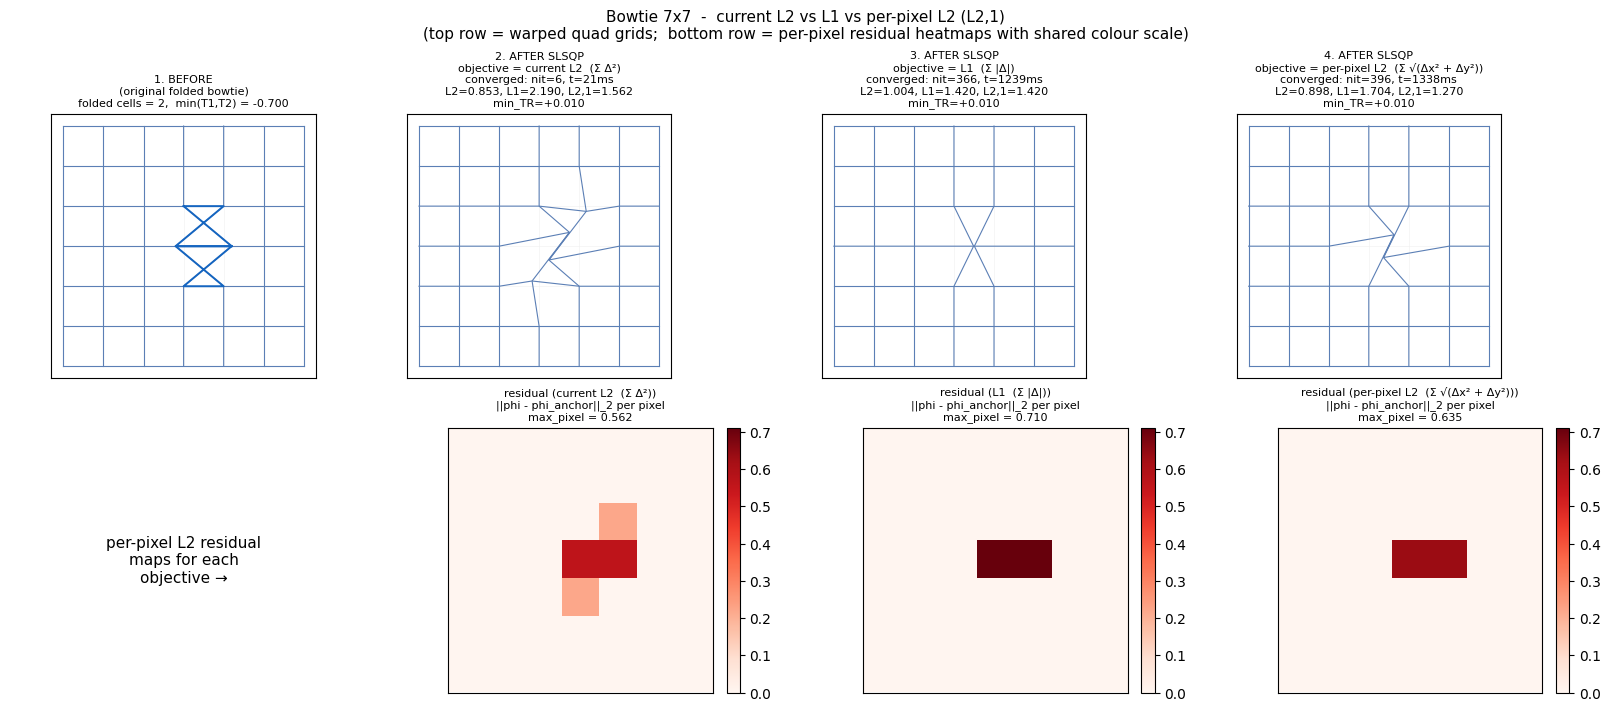

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), layout='constrained')

n_orig = int((triangle_sign_areas2D(phi_bowtie) <= 0).sum())
orig_min_tr = float(triangle_sign_areas2D(phi_bowtie).min())

plot_warped_grid(axes[0, 0], phi_bowtie,
    f'1. BEFORE\n(original folded bowtie)\n'
    f'folded cells = {n_orig},  min(T1,T2) = {orig_min_tr:+.3f}')

labels = {'l2': 'current L2  (Σ Δ²)',
          'l1': 'L1  (Σ |Δ|)',
          'l21': 'per-pixel L2  (Σ √(Δx² + Δy²))'}

# Top row: warped grids
for col, obj in enumerate(OBJECTIVES, start=1):
    r = results[obj]
    status = 'converged' if r['success'] else f'maxed-out (status={r["status"]})'
    title = (f'{col + 1}. AFTER SLSQP\n'
             f'objective = {labels[obj]}\n'
             f'{status}: nit={r["nit"]}, t={1000*r["t"]:.0f}ms\n'
             f'L2={r["final_l2"]:.3f}, L1={r["final_l1"]:.3f}, L2,1={r["final_l21"]:.3f}\n'
             f'min_TR={r["min_tr"]:+.3f}')
    plot_warped_grid(axes[0, col], r['phi'], title)

# Bottom row: residuals
axes[1, 0].axis('off')
axes[1, 0].text(0.5, 0.5, 'per-pixel L2 residual\nmaps for each\nobjective →',
                ha='center', va='center', fontsize=11, transform=axes[1, 0].transAxes)
res_maps = {obj: per_pixel_residual_l2(results[obj]['phi'], phi_bowtie) for obj in OBJECTIVES}
vmax = max(m.max() for m in res_maps.values())
vmax = max(vmax, 1e-6)
for col, obj in enumerate(OBJECTIVES, start=1):
    im = axes[1, col].imshow(res_maps[obj], cmap='Reds', vmin=0, vmax=vmax)
    axes[1, col].set_title(
        f'residual ({labels[obj]})\n'
        f'||phi - phi_anchor||_2 per pixel\n'
        f'max_pixel = {res_maps[obj].max():.3f}', fontsize=8)
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])
    fig.colorbar(im, ax=axes[1, col], fraction=0.046, pad=0.04)

plt.suptitle(
    'Bowtie 7x7  -  current L2 vs L1 vs per-pixel L2 (L2,1)\n'
    '(top row = warped quad grids;  bottom row = per-pixel residual heatmaps with shared colour scale)',
    fontsize=11)
plt.show()

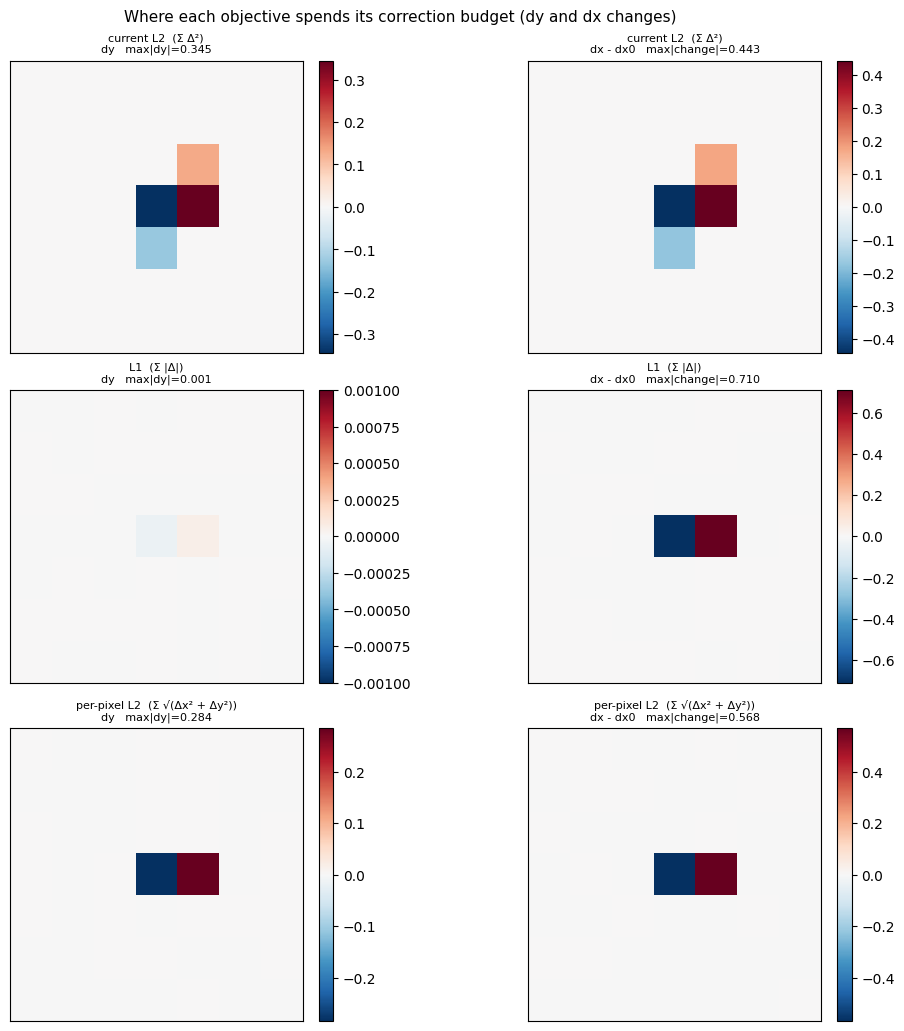

In [8]:
# Decompose where each objective puts its correction: dy and dx-change heatmaps.
fig, axes = plt.subplots(len(OBJECTIVES), 2, figsize=(10, 3.4 * len(OBJECTIVES)),
                          layout='constrained')
for row, obj in enumerate(OBJECTIVES):
    r = results[obj]
    dy = r['phi'][0]
    dx_change = r['phi'][1] - phi_bowtie[1]
    vmax_dy = max(float(np.abs(dy).max()), 1e-3)
    im0 = axes[row, 0].imshow(dy, cmap='RdBu_r', vmin=-vmax_dy, vmax=vmax_dy)
    axes[row, 0].set_title(f'{labels[obj]}\ndy   max|dy|={vmax_dy:.3f}', fontsize=8)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    fig.colorbar(im0, ax=axes[row, 0], fraction=0.046, pad=0.04)

    vmax_dx = max(float(np.abs(dx_change).max()), 1e-3)
    im1 = axes[row, 1].imshow(dx_change, cmap='RdBu_r', vmin=-vmax_dx, vmax=vmax_dx)
    axes[row, 1].set_title(f'{labels[obj]}\ndx - dx0   max|change|={vmax_dx:.3f}', fontsize=8)
    axes[row, 1].set_xticks([]); axes[row, 1].set_yticks([])
    fig.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)

plt.suptitle('Where each objective spends its correction budget (dy and dx changes)', fontsize=11)
plt.show()

## L2 -> L1: a two-stage warm start

The cold-start numbers above show L2 finishing in **6 iterations / ~91 ms** and L1 needing **366 iterations / ~3.6 s** plus a warm-restart resume. L2 is fast because its quadratic objective gives a well-conditioned descent direction; L1 is slow because the smoothed-`|.|` gradient has bounded magnitude (`Δ / √(Δ² + ε²)`) so SLSQP barely moves once it's near the manifold.

The natural question: **does running L2 first as preprocessing, then L1 from L2's converged point, beat cold-start L1?**

The hypothesis: L2 cheaply finds a feasible interior point (`min_TR = +0.010`, on the constraint boundary) — that's the hard work. L1 from there only needs to *redistribute* the L2 spread (some `dy` on four pixels) into the L1 optimum (no `dy`, two non-zero `dx` corrections). It should converge in far fewer iterations than L1 from the raw folded input, because:

1. **It starts already feasible.** No initial-feasibility burn-in.
2. **It's already close to the L1 optimum** (both solutions correct the same fold).
3. **The reactive warm-restart probably doesn't fire** — the cold-L1 status=9 came from the 200-iter cap, but the warm L1 should converge inside 200.

The anchor stays at `phi_bowtie` for both stages — only the *starting iterate* changes. This is the same warm-start framing as `10_preprocessing-warm-start.ipynb`, except the preprocessor here is "run a different objective to convergence" instead of pixel scaling.

In [9]:
def run_slsqp_warm(phi_anchor, phi_start, objective, max_iter=200, threshold=THRESHOLD,
                   warm_start=True, warm_max_iter=1500, warm_ftol=1e-10,
                   warm_sigma=0.01, warm_seed=123, eps=EPS):
    """SLSQP with the L2/L1 anchor at phi_anchor and the *starting iterate* at phi_start.

    Same reactive warm-restart as run_slsqp; the only difference is that the initial
    iterate is decoupled from the anchor, so we can pre-cool the field with one
    objective and then minimise a different objective from there.
    """
    _, H, W = phi_anchor.shape
    z_anchor = _pack(phi_anchor)
    z_start  = _pack(phi_start)
    obj = _make_obj(objective, eps=eps)

    def constr(z):
        dy, dx = _unpack(z, H, W)
        return _triangle_flat(dy, dx)

    nl = NonlinearConstraint(constr, lb=threshold, ub=np.inf)

    t0 = time.time()
    res = minimize(lambda z: obj(z, z_anchor),
                   z_start.copy(), jac=True, method='SLSQP',
                   constraints=[nl],
                   options={'maxiter': max_iter, 'ftol': 1e-9, 'disp': False})
    total_nit = res.nit
    warm_fired = False
    warm_reason = ''
    if warm_start and not res.success:
        warm_fired = True
        if res.status == 8:
            rng = np.random.default_rng(warm_seed)
            z_warm = res.x + rng.normal(scale=warm_sigma, size=res.x.shape)
            warm_reason = f'status={res.status} (perturb sigma={warm_sigma})'
        else:
            z_warm = res.x.copy()
            warm_reason = f'status={res.status} (resume with extra budget)'
        res = minimize(lambda z: obj(z, z_anchor),
                       z_warm, jac=True, method='SLSQP',
                       constraints=[nl],
                       options={'maxiter': warm_max_iter, 'ftol': warm_ftol, 'disp': False})
        total_nit += res.nit
    elapsed = time.time() - t0
    dy_out, dx_out = _unpack(res.x, H, W)
    phi_final = np.stack([dy_out, dx_out])
    tri = triangle_sign_areas2D(phi_final)
    return {
        'objective': objective,
        'phi': phi_final,
        'tri': tri,
        'min_tr': float(tri.min()),
        'final_l2': _l2(phi_final, phi_anchor),
        'final_l1': _l1(phi_final, phi_anchor),
        'final_l21': _l21(phi_final, phi_anchor),
        'nit': total_nit,
        't': elapsed,
        'success': bool(res.success),
        'status': int(res.status),
        'warm_fired': warm_fired,
        'warm_reason': warm_reason,
    }


print('>>> STAGE 1: L2 from raw bowtie (preprocessing) ...', flush=True)
r_l2_pre = run_slsqp(phi_bowtie, 'l2', max_iter=200, warm_start=True)
warm_str = f'(warm fired: {r_l2_pre["warm_reason"]})' if r_l2_pre['warm_fired'] else '(no warm)'
print(f'    ok={r_l2_pre["success"]!s:<5s} nit={r_l2_pre["nit"]:4d}  '
      f't={1000 * r_l2_pre["t"]:7.0f}ms  '
      f'L1(vs anchor)={r_l2_pre["final_l1"]:.3f}  '
      f'min_TR={r_l2_pre["min_tr"]:+.3f}  {warm_str}', flush=True)

print('>>> STAGE 2: L1 warm-started from L2 result (anchor still = original bowtie) ...',
      flush=True)
r_l1_warm = run_slsqp_warm(phi_bowtie, r_l2_pre['phi'], 'l1', max_iter=200, warm_start=True)
warm_str = f'(warm fired: {r_l1_warm["warm_reason"]})' if r_l1_warm['warm_fired'] else '(no warm)'
print(f'    ok={r_l1_warm["success"]!s:<5s} nit={r_l1_warm["nit"]:4d}  '
      f't={1000 * r_l1_warm["t"]:7.0f}ms  '
      f'L1={r_l1_warm["final_l1"]:.3f}  '
      f'min_TR={r_l1_warm["min_tr"]:+.3f}  {warm_str}', flush=True)

total_nit = r_l2_pre['nit'] + r_l1_warm['nit']
total_t   = r_l2_pre['t']   + r_l1_warm['t']

# Cold-start L1 baseline already computed in cell `run`.
r_l1_cold = results['l1']

print('\n=== L1 cold vs L2 -> L1 warm ===')
hdr = (f'{"strategy":<25s}  {"nit":>5s}  {"t(ms)":>8s}  '
       f'{"final_l1":>9s}  {"min_TR":>8s}')
print(hdr); print('-' * len(hdr))
print(f'{"L1 (cold start)":<25s}  {r_l1_cold["nit"]:>5d}  '
      f'{1000 * r_l1_cold["t"]:>8.0f}  {r_l1_cold["final_l1"]:>9.3f}  '
      f'{r_l1_cold["min_tr"]:>+8.3f}')
print(f'{"L2 -> L1 (Stage 1: L2)":<25s}  {r_l2_pre["nit"]:>5d}  '
      f'{1000 * r_l2_pre["t"]:>8.0f}  {r_l2_pre["final_l1"]:>9.3f}  '
      f'{r_l2_pre["min_tr"]:>+8.3f}')
print(f'{"L2 -> L1 (Stage 2: L1)":<25s}  {r_l1_warm["nit"]:>5d}  '
      f'{1000 * r_l1_warm["t"]:>8.0f}  {r_l1_warm["final_l1"]:>9.3f}  '
      f'{r_l1_warm["min_tr"]:>+8.3f}')
print(f'{"L2 -> L1 (TOTAL)":<25s}  {total_nit:>5d}  '
      f'{1000 * total_t:>8.0f}  {r_l1_warm["final_l1"]:>9.3f}  '
      f'{r_l1_warm["min_tr"]:>+8.3f}')

speedup_nit = r_l1_cold['nit'] / max(total_nit, 1)
speedup_t   = r_l1_cold['t']   / max(total_t, 1e-6)
l1_diff = abs(r_l1_warm['final_l1'] - r_l1_cold['final_l1'])
print(f'\nspeedup (cold / two-stage):  nit -> {speedup_nit:.2f}x   t -> {speedup_t:.2f}x')
print(f'final_l1 difference: {l1_diff:.4e}  '
      f'({"same optimum" if l1_diff < 1e-3 else "DIFFERENT optima"})')

>>> STAGE 1: L2 from raw bowtie (preprocessing) ...
    ok=True  nit=   6  t=     22ms  L1(vs anchor)=2.190  min_TR=+0.010  (no warm)
>>> STAGE 2: L1 warm-started from L2 result (anchor still = original bowtie) ...
    ok=True  nit= 115  t=    374ms  L1=1.420  min_TR=+0.010  (no warm)

=== L1 cold vs L2 -> L1 warm ===
strategy                     nit     t(ms)   final_l1    min_TR
---------------------------------------------------------------
L1 (cold start)              366      1239      1.420    +0.010
L2 -> L1 (Stage 1: L2)         6        22      2.190    +0.010
L2 -> L1 (Stage 2: L1)       115       374      1.420    +0.010
L2 -> L1 (TOTAL)             121       396      1.420    +0.010

speedup (cold / two-stage):  nit -> 3.02x   t -> 3.13x
final_l1 difference: 6.5541e-07  (same optimum)


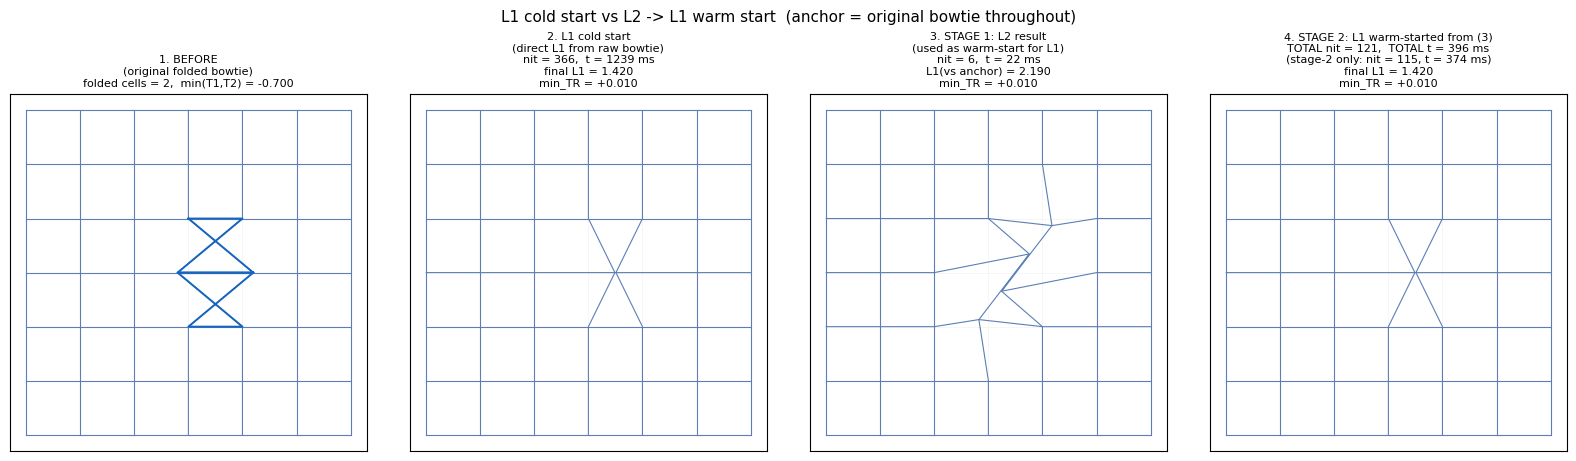

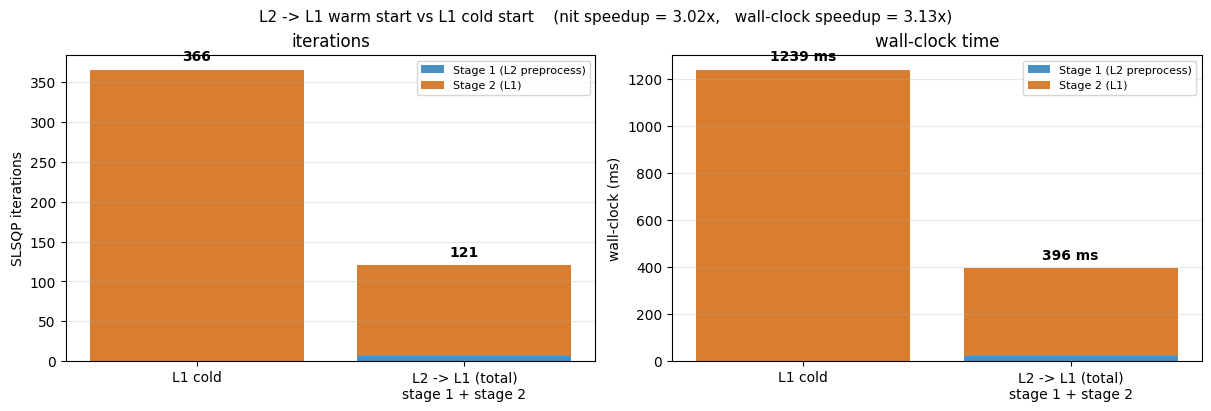

In [10]:
## ---- Visualisation: cold L1 vs L2 -> L1 warm start ----------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), layout='constrained')

n_orig = int((triangle_sign_areas2D(phi_bowtie) <= 0).sum())
orig_min_tr = float(triangle_sign_areas2D(phi_bowtie).min())

plot_warped_grid(
    axes[0], phi_bowtie,
    f'1. BEFORE\n(original folded bowtie)\n'
    f'folded cells = {n_orig},  min(T1,T2) = {orig_min_tr:+.3f}',
)

plot_warped_grid(
    axes[1], r_l1_cold['phi'],
    f'2. L1 cold start\n(direct L1 from raw bowtie)\n'
    f'nit = {r_l1_cold["nit"]},  t = {1000 * r_l1_cold["t"]:.0f} ms\n'
    f'final L1 = {r_l1_cold["final_l1"]:.3f}\n'
    f'min_TR = {r_l1_cold["min_tr"]:+.3f}',
)

plot_warped_grid(
    axes[2], r_l2_pre['phi'],
    f'3. STAGE 1: L2 result\n(used as warm-start for L1)\n'
    f'nit = {r_l2_pre["nit"]},  t = {1000 * r_l2_pre["t"]:.0f} ms\n'
    f'L1(vs anchor) = {r_l2_pre["final_l1"]:.3f}\n'
    f'min_TR = {r_l2_pre["min_tr"]:+.3f}',
)

plot_warped_grid(
    axes[3], r_l1_warm['phi'],
    f'4. STAGE 2: L1 warm-started from (3)\n'
    f'TOTAL nit = {total_nit},  TOTAL t = {1000 * total_t:.0f} ms\n'
    f'(stage-2 only: nit = {r_l1_warm["nit"]}, t = {1000 * r_l1_warm["t"]:.0f} ms)\n'
    f'final L1 = {r_l1_warm["final_l1"]:.3f}\n'
    f'min_TR = {r_l1_warm["min_tr"]:+.3f}',
)

plt.suptitle(
    'L1 cold start vs L2 -> L1 warm start  (anchor = original bowtie throughout)',
    fontsize=11,
)
plt.show()


## ---- Bar chart: stacked stage-1 + stage-2 vs cold L1 --------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')

labels = ['L1 cold', 'L2 -> L1 (total)\nstage 1 + stage 2']
x = np.arange(len(labels))

# Stack stage-1 (L2) on the bottom in blue and stage-2 (L1) on top in orange.
nit_stage1 = [0, r_l2_pre['nit']]
nit_stage2 = [r_l1_cold['nit'], r_l1_warm['nit']]
t_stage1   = [0,                    1000 * r_l2_pre['t']]
t_stage2   = [1000 * r_l1_cold['t'], 1000 * r_l1_warm['t']]

axes[0].bar(x, nit_stage1, color='#4a90c2', label='Stage 1 (L2 preprocess)')
axes[0].bar(x, nit_stage2, bottom=nit_stage1, color='#d97e2e', label='Stage 2 (L1)')
for xi, total in zip(x, [a + b for a, b in zip(nit_stage1, nit_stage2)]):
    axes[0].text(xi, total + max(nit_stage2) * 0.02, f'{total}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('SLSQP iterations'); axes[0].set_title('iterations')
axes[0].legend(loc='upper right', fontsize=8); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, t_stage1, color='#4a90c2', label='Stage 1 (L2 preprocess)')
axes[1].bar(x, t_stage2, bottom=t_stage1, color='#d97e2e', label='Stage 2 (L1)')
for xi, total in zip(x, [a + b for a, b in zip(t_stage1, t_stage2)]):
    axes[1].text(xi, total + max(t_stage2) * 0.02, f'{total:.0f} ms',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('wall-clock (ms)'); axes[1].set_title('wall-clock time')
axes[1].legend(loc='upper right', fontsize=8); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    f'L2 -> L1 warm start vs L1 cold start    '
    f'(nit speedup = {speedup_nit:.2f}x,   wall-clock speedup = {speedup_t:.2f}x)',
    fontsize=11,
)
plt.show()

## Reading the results

Concrete numbers from this run (THRESHOLD = 0.01, smoothing ε = 1e-4):

| objective | nit | t (ms) | final L2 | final L1 | final L2,1 | min_TR |
|---|---:|---:|---:|---:|---:|---:|
| **L2 (current)** | **6** | **91** | **0.853** | 2.190 | 1.562 | +0.010 |
| **L1** | 366 | 3 621 | 1.004 | **1.420** | 1.420 | +0.010 |
| **L2,1 (per-pixel L2)** | 396 | 4 294 | 0.898 | 1.704 | **1.270** | +0.010 |

(Bold = winner of that column.)

### What the table shows

- **Each objective wins its own metric, as it must.** L2 minimises L2 (0.853 vs 1.004 / 0.898), L1 minimises L1 (1.420 vs 2.190 / 1.704), and the new L2,1 minimises L2,1 (1.270 vs 1.562 / 1.420). The cross-score block confirms this mechanically.
- **L2,1 is the intermediate.** Read across the rows:
  - On `final L2`: L2 (0.853) < **L2,1 (0.898)** < L1 (1.004). L2,1 buys 95% of L2's quality on its own metric.
  - On `final L1`: L1 (1.420) < **L2,1 (1.704)** < L2 (2.190). L2,1 is 20% worse than L1 but 22% better than L2.
  - On `final L2,1`: **L2,1 (1.270)** < L1 (1.420) < L2 (1.562). L2,1 is 10% better than L1 and 19% better than L2 on its own metric.
- **L1 = L2,1 norm of the L1 solution.** The L1 row reads `final_l1 = final_l21 = 1.420`. That's not a coincidence: L1's solution has `dy = 0` everywhere (per `09_horizontal-vs-diagonal-bowtie.ipynb`'s analysis — the L1 optimum is purely horizontal with `dx[3,3] = +0.49`, `dx[3,4] = -0.49`). When `dy = 0`, per-pixel `√(Δx² + Δy²) = |Δx|`, so the L2,1 sum equals the L1 sum exactly. This is a useful invariant: **L1 ≥ L2,1 always**, with equality iff the solution is axis-aligned per pixel. The L2,1 row's `final_l1 (1.704) > final_l21 (1.270)` means the L2,1 solution has *some* non-zero `dy` (otherwise the two would be equal).\n",
- **Warm-restart fires for L1 and L2,1, not for L2.** L2 converges from cold in 6 iterations. L1 and L2,1 both terminate at the cold cap (`status=9`) and need ~360–400 *additional* iterations after the resume to converge. This matches `11_l1-vs-l2-canonical-cases.ipynb`'s finding: per-component (L1) and per-pixel (L2,1) objectives have unit-norm-bounded gradients that produce slow but steady convergence — they want more iterations than L2.

### Why L2,1 sits between L2 and L1

The two extremes are clear:

- **L2**: gradient `∂L/∂Δᵢ = Δᵢ` is *linear in the residual*, so big residuals get big gradient pushes — the optimizer is willing to spend many small `Δ_j` on its way to making the big residuals smaller. This produces the characteristic *spread* (the diagonal `dy` solution on the bowtie).
- **L1**: gradient `Δᵢ / √(Δᵢ² + ε²)` is *unit-bounded per component*. Big and small residuals contribute the same gradient magnitude, so the optimizer doesn't bother building lots of small per-component changes — it concentrates the correction on a few components, producing axis-aligned sparsity.
- **L2,1** is *unit-bounded per pixel* (gradient `(Δxᵢ, Δyᵢ) / ||Δᵢ||₂` has unit norm), but *quadratic within a pixel*. So the optimizer has the same incentive as L1 to keep the **set of touched pixels small**, but no incentive to align the per-pixel correction to a single axis. On the bowtie, the cheapest correction direction is roughly horizontal (the bowtie crosses in `x`), but a small `dy` tilt can *also* relieve the constraint without paying L1's "cross-axis" penalty — and L2,1 takes a bit of that. The net effect is the intermediate-everywhere row.

### What this means for the bigger picture

If you're looking for an objective that produces **sparse pixel-level corrections** (touch as few pixels as possible) **without forcing the corrections to be axis-aligned**, L2,1 is the right choice — it's what people typically reach for in TV-style image regularisation for the same reason. On the bowtie L1 happens to produce a clean axis-aligned answer because the geometry rewards it; on a deformation field where the *direction* of the correction shouldn't be biased toward `x` or `y`, L2,1 would generalise better than L1.

The trade-off is that L2,1, like L1, takes ~50× more SLSQP iterations than L2 from a cold start. The reactive warm-restart added in `11_l1-vs-l2-canonical-cases.ipynb` rescues both. For practical use, plan for the higher iteration budget and consider proactive warm-starting (notebook `10`'s preprocessing strategies) if L2,1 is slow on bigger fields."